# Ι Proyecto Iota | Recomendación de Planes de Megaline

## Contexto empresarial

Megaline es una compañía de telecomunicaciones que busca migrar a sus clientes desde planes heredados hacia sus nuevas tarifas comerciales: **Smart** y **Ultra**.

La empresa dispone de información histórica sobre clientes que ya adoptaron los nuevos planes. Utilizando estos datos, el objetivo es construir un modelo de aprendizaje automático capaz de analizar el comportamiento mensual de un usuario y recomendar automáticamente el plan más adecuado.

Este problema puede abordarse mediante técnicas de clasificación supervisada, donde el modelo aprende patrones a partir de ejemplos históricos para predecir la tarifa más apropiada para nuevos clientes.

## Objetivos

- Explorar y comprender el conjunto de datos.
- Preparar los datos para el entrenamiento de modelos de clasificación.
- Dividir la información en conjuntos de entrenamiento, validación y prueba.
- Entrenar diferentes algoritmos de Machine Learning.
- Ajustar hiperparámetros para optimizar el rendimiento.
- Comparar el desempeño de los modelos candidatos.
- Seleccionar el modelo con mayor exactitud.
- Verificar que el rendimiento supere el umbral mínimo de exactitud establecido por Megaline.
- Realizar una prueba de cordura para validar la utilidad del modelo seleccionado.

## Conjunto de datos utilizado

- `users_behavior.csv`

## Variables disponibles

- `calls` — número de llamadas realizadas.
- `minutes` — duración total de llamadas en minutos.
- `messages` — cantidad de mensajes enviados.
- `mb_used` — tráfico de internet consumido en MB.
- `is_ultra` — variable objetivo:
  - 1 = Ultra
  - 0 = Smart

## Tipo de problema

**Clasificación supervisada binaria**

El objetivo consiste en predecir si un usuario debe ser asignado al plan:

- Smart (0)
- Ultra (1)

## Métrica principal

- Accuracy (Exactitud)

## Criterio de éxito

El modelo final deberá alcanzar una exactitud mínima de:

```text
0.75
```

en el conjunto de prueba.

## Pregunta de negocio

**¿Es posible predecir correctamente qué plan (Smart o Ultra) se adapta mejor a un cliente utilizando únicamente su comportamiento mensual de llamadas, mensajes y consumo de internet?**

Primero procederemos con la carga de datos con una exploración inicial del dataset tanto de forma general como con una pequeña muestra para entender su naturaleza.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/users_behavior.csv')

df.info()

df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


,calls,minutes,messages,mb_used,is_ultra
13,56.0,433.07,16.0,16702.36,0
2640,87.0,621.03,72.0,10691.46,0
2721,68.0,433.18,90.0,23446.54,0
931,59.0,376.65,32.0,14791.39,1
718,94.0,641.46,17.0,16670.23,1


Continuaremos con una limpieza general de ser necesario

In [ ]:
# Búsqueda de valores ausentes a pesar de que la información general nos dice que no
df.isna().sum()

,0
calls,0
minutes,0
messages,0
mb_used,0
is_ultra,0


In [ ]:
# Búsqueda de valores duplicados explícitos
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
3209,False
3210,False
3211,False
3212,False


In [ ]:
# Búsqueda de valores duplicados implícitos
pd.unique(df.values.ravel())

array([   40.  ,   311.9 ,    83.  , ..., 31239.78,   566.09, 29480.52])

Podemos proceder con la construcción del modelo de aprendizaje, dado que se trata de predecir cual será el mejor plan para recomendar a los clientes podemos apartar el modelo de regresión lineal ya que este nos ayuda a predecir cantidades numéricas continuas.

Nos enfocaremos en el estudio de un algoritmo de arbol de desición y un bosque aleatorio

## División del conjunto de datos

Como se trata de un problema de clasificación supervisada, fue necesario dividir el conjunto de datos en tres subconjuntos independientes:

- **Entrenamiento (60%)**: utilizado para ajustar los modelos de Machine Learning.
- **Validación (20%)**: utilizado para comparar modelos y ajustar hiperparámetros.
- **Prueba (20%)**: reservado para evaluar el desempeño final del modelo seleccionado.

Para realizar la división se utilizó el parámetro `stratify`, garantizando que la proporción de usuarios pertenecientes a cada plan se mantuviera constante en todos los subconjuntos.

Posteriormente, se definieron las variables predictoras:

- `calls`
- `minutes`
- `messages`
- `mb_used`

y la variable objetivo:

- `Name_plan` (`Smart` o `Ultra`)

## Verificación de la distribución de clases

Antes de entrenar los modelos, se verificó que la distribución de los planes permaneciera estable en los conjuntos de entrenamiento, validación y prueba.

Los resultados obtenidos fueron:

| Conjunto | Smart | Ultra |
|-----------|--------:|--------:|
| Original | 69.35% | 30.65% |
| Entrenamiento | 69.35% | 30.65% |
| Validación | 69.36% | 30.64% |
| Prueba | 69.36% | 30.64% |

El gráfico de proporciones confirma que las distribuciones son prácticamente idénticas en los cuatro conjuntos. Esto indica que el proceso de estratificación funcionó correctamente y evita que alguno de los subconjuntos presente un sesgo hacia una de las clases.

Mantener esta consistencia es fundamental para garantizar que el rendimiento de los modelos durante las etapas de validación y prueba refleje adecuadamente su capacidad de generalización sobre datos nuevos.

Con los datos correctamente segmentados y balanceados respecto a la distribución original de clases, el conjunto se encuentra listo para iniciar el entrenamiento y la comparación de diferentes modelos de clasificación.

Porcentaje del dataset original
Name_plan
Smart    0.693528
Ultra    0.306472
Name: proportion, dtype: float64

Porcentaje del dataset de entrenamiento
Name_plan
Smart    0.693465
Ultra    0.306535
Name: proportion, dtype: float64

Porcentaje del dataset de validación
Name_plan
Smart    0.693624
Ultra    0.306376
Name: proportion, dtype: float64

Porcentaje del dataset de prueba
Name_plan
Smart    0.693624
Ultra    0.306376
Name: proportion, dtype: float64


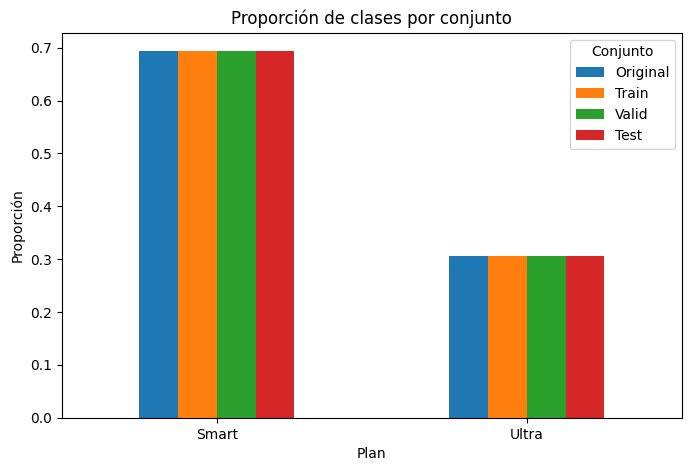

In [ ]:
# Importamos las librerias necesarias para el arbol de desición
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Aunque no lo consideramos necesario dado que los valores de los planes ya estan categorizados (0, 1) reclasificaremos el contenido de esta columna por los nombres de los planes
df.loc[df["is_ultra"] == 1, "Name_plan"] = "Ultra"
df.loc[df["is_ultra"] == 0, "Name_plan"] = "Smart"

# Dividiremos el dataset en conjuntos de entrenamiento y temporal primero
df_train, df_temp = train_test_split(df, random_state = 5, test_size = 0.4, stratify = df["Name_plan"])

# Luego dejaremos de lado el dataset de entrenamiento y dividiremos el dataset temporal en validación y prueba
df_valid, df_test = train_test_split(df_temp, random_state = 5, test_size = 0.5, stratify = df_temp["Name_plan"])

# Seleccionamos nuestras variables predictoras(caraterísticas) y el objetivo a predecir en el conjunto de entrenamiento, validación y prueba

# Caraterísticas y obejtivo en el dataset de entrenamiento
features_train = df_train.drop(["is_ultra", "Name_plan"], axis = 1)
target_train = df_train["Name_plan"]

# Caraterísticas y obejtivo en el dataset de validación
features_valid = df_valid.drop(["is_ultra", "Name_plan"], axis = 1)
target_valid = df_valid["Name_plan"]

# Caraterísticas y obejtivo en el dataset de prueba
features_test = df_test.drop(["is_ultra", "Name_plan"], axis = 1)
target_test = df_test["Name_plan"]

# Verificamos y graficamos la correcta distribución de las cantidades de información que prevemos para los 3 conjuntos del dataset original
print("Porcentaje del dataset original")
print(df["Name_plan"].value_counts(normalize = True))

print("\nPorcentaje del dataset de entrenamiento")
print(df_train["Name_plan"].value_counts(normalize = True))

print("\nPorcentaje del dataset de validación")
print(df_valid["Name_plan"].value_counts(normalize = True))

print("\nPorcentaje del dataset de prueba")
print(df_test["Name_plan"].value_counts(normalize = True))


# Calculamos la proporción de cada dataset
original_prop = df["Name_plan"].value_counts(normalize = True)
train_prop = df_train["Name_plan"].value_counts(normalize = True)
valid_prop = df_valid["Name_plan"].value_counts(normalize = True)
test_prop = df_test["Name_plan"].value_counts(normalize = True)


# Convertimos esta información en un dataset para fraficación

comparacion = pd.DataFrame({
    "Original": original_prop,
    "Train": train_prop,
    "Valid": valid_prop,
    "Test": test_prop
})

comparacion.plot(kind="bar", figsize=(8, 5))
plt.title("Proporción de clases por conjunto")
plt.ylabel("Proporción")
plt.xlabel("Plan")
plt.xticks(rotation=0)
plt.legend(title="Conjunto")
plt.show()

Construímos el modelo de Arbol de decisión y evaluamos cual es la mejor profundidad por medio de un bucle

In [ ]:
best_depth = 0
best_accuracy = 0
best_model = None

for depth in range(1, 61):
    modeltree = DecisionTreeClassifier(max_depth = depth, random_state = 5)
    modeltree.fit(features_train, target_train)
    prediction_valid = modeltree.predict(features_valid)
    accuracy = accuracy_score(target_valid, prediction_valid)

    print("Profundidad del arbol:", depth)
    print("Exactitud del arbol:", accuracy)

    if accuracy > best_accuracy:
       best_depth = depth
       best_accuracy = accuracy
       best_model = modeltree
       print("MODELO CON LA MEJOR EXACTITUD",best_depth, best_accuracy, best_model)

Profundidad del arbol: 1
Exactitud del arbol: 0.7402799377916018
MODELO CON LA MEJOR EXACTITUD 1 0.7402799377916018 DecisionTreeClassifier(max_depth=1, random_state=5)
Profundidad del arbol: 2
Exactitud del arbol: 0.7667185069984448
MODELO CON LA MEJOR EXACTITUD 2 0.7667185069984448 DecisionTreeClassifier(max_depth=2, random_state=5)
Profundidad del arbol: 3
Exactitud del arbol: 0.776049766718507
MODELO CON LA MEJOR EXACTITUD 3 0.776049766718507 DecisionTreeClassifier(max_depth=3, random_state=5)
Profundidad del arbol: 4
Exactitud del arbol: 0.7884914463452566
MODELO CON LA MEJOR EXACTITUD 4 0.7884914463452566 DecisionTreeClassifier(max_depth=4, random_state=5)
Profundidad del arbol: 5
Exactitud del arbol: 0.7853810264385692
Profundidad del arbol: 6
Exactitud del arbol: 0.7900466562986003
MODELO CON LA MEJOR EXACTITUD 6 0.7900466562986003 DecisionTreeClassifier(max_depth=6, random_state=5)
Profundidad del arbol: 7
Exactitud del arbol: 0.7869362363919129
Profundidad del arbol: 8
Exactit

A pesar del extremo incremento incremento paulatino de cada profundidad en el arbol aplicado en el bucle nos pudimos dar cuenta que no hay mejora significativa por no decir que es nula la mejora a partir del modelo de arbol con profundidad de 28.

Nos dimos cuenta que el mejor modelo fue el arbol de DecisionTreeClassifier(max_depth=8, random_state=5) con una exactitud de 0.7962674961119751. Un 79.62% redondeado a 80% de exactitud.

Construcción del bosque aleatorio

In [ ]:
from sklearn.ensemble import RandomForestClassifier

mejor_cantidad_de_arboles = 0
mejor_exactitud = 0
mejor_modelo = None
mejor_profundidad_por_arbol = 0

for profundidad in range(1, 30):
    for n_arboles in range(1, 201, 5):
        modelo_bosque = RandomForestClassifier(n_estimators = n_arboles, max_depth = profundidad, random_state = 5, n_jobs = -1)
        modelo_bosque.fit(features_train, target_train)
        prediccion_valid = modelo_bosque.predict(features_valid)
        exactitud = accuracy_score(target_valid, prediccion_valid)

        if exactitud > mejor_exactitud:
            mejor_cantidad_de_arboles = n_arboles
            mejor_exactitud = exactitud
            mejor_modelo = modelo_bosque
            mejor_profundidad_por_arbol = profundidad
print("EL MEJOR BOSQUE ES:", mejor_modelo, mejor_exactitud, mejor_cantidad_de_arboles, mejor_profundidad_por_arbol)


EL MEJOR BOSQUE ES: RandomForestClassifier(max_depth=12, n_estimators=76, n_jobs=-1, random_state=5) 0.8133748055987559 76 12


Despues de la ejecución de un doble bucle que nos ayuda a calcular el mejor modelo de bosque aleatorio basado en la cantidad de arboles y la profundidad por arbol se llegó a la conclusión de que el modelo del bosque aleatorio es ligeramente mejor en exactitud, dado que con 76 arboles y cada uno con una profundidad de 12 niveles se llegó a una exactitud de 0.8133748055987559, que redondeamos a un 81.33% de exactitud. Esto requirió costo de tiempo en trabajo computacional. Se estudiará la forma de aplicar el hiperparámetro n_jobs = -1 para usar todos los núcleos disponibles del equipo para acelerar el trabajo

In [ ]:
# Procedemos a calcular la diferencia de exactitud de los mejores modelos con los mejores hiperparámetros

diferencia = mejor_exactitud - best_accuracy
diferencia_porcentual = diferencia * 100

print("La diferencia de exactitud entre ambos modelos es de:", diferencia)
print("La diferencia porcentual es de:", diferencia_porcentual)

La diferencia de exactitud entre ambos modelos es de: 0.017107309486780742
La diferencia porcentual es de: 1.7107309486780742


Consideramos que esta diferencia no es tan significativa pero si lo suficiente como para elegir al modelo de bosque aleatorio por encima de un arbol de decisión en este caso de estudio.

Ahora procederemos con implementar el modelo elegido para el dataset de prueba y calcularemos su exactitud.



In [ ]:
Prediccion_del_bosque = mejor_modelo.predict(features_test)
print(Prediccion_del_bosque)
exactitud = accuracy_score(target_test, Prediccion_del_bosque)
print(exactitud)


['Smart' 'Smart' 'Smart' 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Smart'
 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart'
 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart'
 'Smart' 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Ultra' 'Smart' 'Smart'
 'Smart' 'Smart' 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Ultra' 'Ultra'
 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Ultra'
 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Ultra' 'Smart'
 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Ultra'
 'Ultra' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Ultra' 'Smart' 'Ultra'
 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart'
 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Ultra' 'Ultra' 'Smart'
 'Ultra' 'Ultra' 'Smart' 'Smart' 'Ultra' 'Smart' 'Ultra' 'Smart' 'Smart'
 'Smart' 'Smart' 'Ultra' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart' 'Smart'
 'Smart' 'Smart' 'Ultra' 'Smart' 'Ultra' 'Ultra' 'S

Tomando en cuenta el resultado obtenido se llega a la conclusión de que el modelo clasificó los usuarios entre los planes Ultra y Smart, obteniendo una exactitud del 81.8% en el conjunto de prueba.

Sin embargo para asegurarnos que nuestro modelo de bosque aleatorio aprendió algo relevante procederemos a realizar una prueba de cordura sencilla, calcularemos al exactitud de este "modelo falso" y lo compararemos con la exactitud de nuestro bosque.

In [ ]:
from sklearn.dummy import DummyClassifier

bosque_tonto = DummyClassifier(random_state = 5, strategy = "most_frequent")

bosque_tonto.fit(features_valid, target_valid)

prediccion_tonta = bosque_tonto.predict(features_valid)

exactitud_tonta = accuracy_score(target_valid, prediccion_tonta)

print("La exactitud del modelo tonto es de:", exactitud_tonta)
print("La exactitud del modelo de bosque aleatorio es de:", mejor_exactitud)

La exactitud del modelo tonto es de: 0.6936236391912908
La exactitud del modelo de bosque aleatorio es de: 0.8133748055987559


Tomando en cuenta los resultados de la prueba de cordura nos dimos cuenta de que la exactitud en este caso es de 69.36% mientras, la cual es menor a la de nuestro modelo original elegido.

Con esto en consideración podemos afirmar que nuesto modelo asignó a los usuarios en los planes Ultra y Smart con una exactitud final del 81.33%